In [17]:
import numpy as np
import matplotlib.pyplot as plt

# ASSUMPTIONS

https://www.flysfo.com/passengers/parking/plugin-electric-car 

In [19]:
ASSUMPTIONS = {
    # Simulation
    "airport": "SFO",
    "year": 2026,
    "month": 7,
    "interval_minutes": 15,

    # Randomness
    "random_seed": 42,

    # Energy demand
    "energy_per_car": 25,  # kWh

    # Parking / charging ports
    "short_term_ports": 104,
    "long_term_ports": 144,

    # Parking stay duration
    "short_term_stay_hours": 2,
    "long_term_stay_hours": 72,

    # Charger power
    "l1_power_kw": 1.4,
    "l2_power_kw": 7.0,

    # Fraction of ports that are Level 1
    "l1_share": 0.10,

    # Relative probability of arrivals by hour
    # Index 0 = midnight, ..., index 23 = 11 PM
    "arrival_weights": [
        0, 0, 0, 0, 0,
        0, 10, 13, 14, 10,
        7, 5, 5, 5, 6,
        7, 8, 6,
        5, 4, 3, 3, 2, 0,
    ],
}

# empty timeline

In [21]:
import pandas as pd

# Assumptions
start_date = "2026-07-01"
output_start_date = "2026-06-28"
output_end_date = "2026-08-01"

# One row every 15 minutes for July, starting at 0 kW
timeline = pd.DataFrame({
    "timestamp": pd.date_range(
        start=start_date,
        end=output_end_date,
        freq="15min",
        inclusive="left",
        tz="America/Los_Angeles",
    ),
    "load_kw": 0.0,
})

timeline.head()

,timestamp,load_kw
0,2026-07-01 00:00:00-07:00,0.0
1,2026-07-01 00:15:00-07:00,0.0
2,2026-07-01 00:30:00-07:00,0.0
3,2026-07-01 00:45:00-07:00,0.0
4,2026-07-01 01:00:00-07:00,0.0


# calc how many cars arrive each day

In [23]:
occupied_share = .80 

#short term assumptions, hardcoded for now, SFO, https://www.flysfo.com/to-from/parking/plugin-electric-car
short_term_ports = 104
short_term_stay_hrs = 2
busy_hours_per_day = 16

#long term assumptions
long_term_ports = 144
long_term_stay_days = 3 

#average arrivals per day
short_term_cars_per_day = (
    short_term_ports * occupied_share * busy_hours_per_day / short_term_stay_hrs)

long_term_cars_per_day = (
    long_term_ports * occupied_share / long_term_stay_days)

number_of_ports = short_term_ports + long_term_ports

print(short_term_cars_per_day)
print(long_term_cars_per_day)


665.6
38.4


# arrival time and how much energy needed (25 kW for now)
- set upper bound for vehicles generated

In [66]:
import numpy as np
import pandas as pd

rng = np.random.default_rng(ASSUMPTIONS["random_seed"])

weights = np.array(ASSUMPTIONS["arrival_weights"])
probabilities = weights / weights.sum()

# Get each date from existing monthly timeline
days = timeline["timestamp"].dt.normalize().drop_duplicates()

cars = []

for day in days:
    for lot, daily_average in [
        ("short_term", short_term_cars_per_day),
        ("long_term", long_term_cars_per_day),
    ]:
        number_of_cars = rng.poisson(daily_average)

        for _ in range(number_of_cars):
            hour = rng.choice(24, p=probabilities)
            minute = rng.integers(0, 60)

            arrival = day + pd.Timedelta(
                hours=int(hour),
                minutes=int(minute),
            )

            cars.append({
                "lot": lot,
                "arrival": arrival,
                "energy_needed_kwh": ASSUMPTIONS["energy_per_car"],
            })

cars = pd.DataFrame(
    cars,
    columns=["lot", "arrival", "energy_needed_kwh"],
).sort_values(
    "arrival",
    kind="stable"
).reset_index(drop=True)
cars

,lot,arrival,energy_needed_kwh
0,short_term,2026-07-01 06:00:00-07:00,25
1,short_term,2026-07-01 06:00:00-07:00,25
2,short_term,2026-07-01 06:03:00-07:00,25
3,short_term,2026-07-01 06:03:00-07:00,25
4,short_term,2026-07-01 06:04:00-07:00,25
...,...,...,...
21876,short_term,2026-07-31 22:47:00-07:00,25
21877,short_term,2026-07-31 22:50:00-07:00,25
21878,long_term,2026-07-31 22:56:00-07:00,25
21879,short_term,2026-07-31 22:58:00-07:00,25


# Assumptions: 90% L2 and 10% L1 chargers:

In [27]:
# Short-term charger split
short_l1_ports = round(
    ASSUMPTIONS["short_term_ports"] * ASSUMPTIONS["l1_share"]
)

short_l2_ports = (
    ASSUMPTIONS["short_term_ports"] - short_l1_ports
)

# Long-term charger split
long_l1_ports = round(
    ASSUMPTIONS["long_term_ports"] * ASSUMPTIONS["l1_share"]
)

long_l2_ports = (
    ASSUMPTIONS["long_term_ports"] - long_l1_ports
)

In [29]:
l1_hours = (
    ASSUMPTIONS["energy_per_car"]
    / ASSUMPTIONS["l1_power_kw"]
)

l2_hours = (
    ASSUMPTIONS["energy_per_car"]
    / ASSUMPTIONS["l2_power_kw"]
)

print(l1_hours)
print(l2_hours)

17.857142857142858
3.5714285714285716


## assumptions in this block: short term cars connected to L2 leave before reaching 25 kWh, short term cars connected to L1 leave before reaching 2.8. 

L2: 7 kW * 2 hrs = 14
L1: 1.4 kW * 2 hrs = 2.8

In [64]:
# Create the ports using L1/L2 counts

ports = {
    "short_term": [
        {"power_kw": power, "free_at": None}
        for power in (
            [ASSUMPTIONS["l1_power_kw"]] * short_l1_ports
            + [ASSUMPTIONS["l2_power_kw"]] * short_l2_ports
        )
    ],

    "long_term": [
        {"power_kw": power, "free_at": None}
        for power in (
            [ASSUMPTIONS["l1_power_kw"]] * long_l1_ports
            + [ASSUMPTIONS["l2_power_kw"]] * long_l2_ports
        )
    ],
}

stay_hours = {
    "short_term": ASSUMPTIONS["short_term_stay_hours"],
    "long_term": ASSUMPTIONS["long_term_stay_hours"],
}

rng = np.random.default_rng(ASSUMPTIONS["random_seed"])

# Reset results so rerunning does not double the load
timeline["load_kw"] = 0.0

cars = cars.sort_values(
    "arrival",
    kind="stable"
).reset_index(drop=True)
cars["port_power_kw"] = 0.0
cars["charging_hours"] = 0.0

interval = pd.Timedelta(
    minutes=ASSUMPTIONS["interval_minutes"]
)

for car_id, car in cars.iterrows():

    arrival = car["arrival"]
    lot = car["lot"]

    # Find ports that are free when this car arrives
    available = [
        port for port in ports[lot]
        if port["free_at"] is None or port["free_at"] <= arrival
    ]

    if not available:
        continue  # Car cannot charge

    # Randomly choose one of the available ports
    port = available[int(rng.integers(len(available)))]
    power_kw = port["power_kw"]

    departure = arrival + pd.Timedelta(
        hours=stay_hours[lot]
    )

    # Block port for the entire parking stay
    port["free_at"] = departure

    #
    charging_hours = min(
        car["energy_needed_kwh"] / power_kw,
        stay_hours[lot],
    )

    charge_end = arrival + pd.Timedelta(
        hours=charging_hours
    )

    cars.loc[car_id, "accepted"] = True
    cars.loc[car_id, "port_power_kw"] = power_kw
    cars.loc[car_id, "charging_hours"] = charging_hours

    # Find timeline intervals that overlap this charging session
    overlaps = (
        (timeline["timestamp"] < charge_end)
        & (timeline["timestamp"] + interval > arrival)
    )

    for row in timeline.index[overlaps]:

        interval_start = timeline.loc[row, "timestamp"]
        interval_end = interval_start + interval

        charging_minutes = (
            min(charge_end, interval_end)
            - max(arrival, interval_start)
        ).total_seconds() / 60

        timeline.loc[row, "load_kw"] += (
            power_kw
            * charging_minutes
            / ASSUMPTIONS["interval_minutes"]
        )

print(
    "Cars unable to plug in:",
    int((~cars["accepted"]).sum())
)

timeline.head(40)

Cars unable to plug in: 2284


,timestamp,load_kw
0,2026-07-01 00:00:00-07:00,0.000000
1,2026-07-01 00:15:00-07:00,0.000000
2,2026-07-01 00:30:00-07:00,0.000000
3,2026-07-01 00:45:00-07:00,0.000000
4,2026-07-01 01:00:00-07:00,0.000000
5,2026-07-01 01:15:00-07:00,0.000000
6,2026-07-01 01:30:00-07:00,0.000000
7,2026-07-01 01:45:00-07:00,0.000000
8,2026-07-01 02:00:00-07:00,0.000000
9,2026-07-01 02:15:00-07:00,0.000000


In [36]:
cars.groupby("lot")["accepted"].agg(
    total="count",
    accepted="sum"
)

,total,accepted
lot,,
long_term,1188,1188
short_term,20693,18409


In [38]:
summary = cars.groupby("lot")["accepted"].agg(
    total_cars="count",
    accepted="sum"
)

summary["rejected"] = (
    summary["total_cars"] - summary["accepted"]
)

summary["rejection_rate"] = (
    summary["rejected"] / summary["total_cars"]
)

summary

,total_cars,accepted,rejected,rejection_rate
lot,,,,
long_term,1188,1188,0,0.000000
short_term,20693,18409,2284,0.110375


## rejection rate of vehicle seems high for short term parking. Checking how many cars i generate per hour, need to change short term stay of 2 hrs. check the distribution


In [81]:
print(cars.groupby("lot").size())

lot
long_term      1188
short_term    20693
dtype: int64


In [40]:
print(cars.groupby("lot")["accepted"].agg(["count", "sum"]))

            count    sum
lot                     
long_term    1188   1188
short_term  20693  18409


In [42]:
short = cars[cars["lot"] == "short_term"].copy()

short["hour"] = short["arrival"].dt.floor("h")

short.groupby("hour").size().sort_values(ascending=False).head(20)

hour
2026-07-05 08:00:00-07:00    112
2026-07-23 08:00:00-07:00    104
2026-07-13 07:00:00-07:00    102
2026-07-18 08:00:00-07:00    102
2026-07-25 08:00:00-07:00    100
2026-07-01 07:00:00-07:00     98
2026-07-12 07:00:00-07:00     92
2026-07-15 08:00:00-07:00     92
2026-07-13 08:00:00-07:00     91
2026-07-14 08:00:00-07:00     91
2026-07-19 08:00:00-07:00     89
2026-07-10 08:00:00-07:00     88
2026-07-31 08:00:00-07:00     88
2026-07-21 07:00:00-07:00     88
2026-07-16 08:00:00-07:00     88
2026-07-17 08:00:00-07:00     86
2026-07-12 08:00:00-07:00     86
2026-07-16 07:00:00-07:00     86
2026-07-11 08:00:00-07:00     86
2026-07-29 08:00:00-07:00     85
dtype: int64

In [44]:
# Total kW per interval
timeline[["timestamp", "load_kw"]].head(20)


,timestamp,load_kw
0,2026-07-01 00:00:00-07:00,0.0
1,2026-07-01 00:15:00-07:00,0.0
2,2026-07-01 00:30:00-07:00,0.0
3,2026-07-01 00:45:00-07:00,0.0
4,2026-07-01 01:00:00-07:00,0.0
5,2026-07-01 01:15:00-07:00,0.0
6,2026-07-01 01:30:00-07:00,0.0
7,2026-07-01 01:45:00-07:00,0.0
8,2026-07-01 02:00:00-07:00,0.0
9,2026-07-01 02:15:00-07:00,0.0


In [52]:
load_profile = timeline[
    (timeline["timestamp"] >= output_start_date)
    & (timeline["timestamp"] < output_end_date)
][["timestamp", "load_kw"]].copy()

load_profile = load_profile.rename(
    columns={"load_kw": "kW"}
)

load_profile.to_csv(
    "loadprofile_SFO_2026-07.csv",
    index=False
)


,timestamp,kW
0,2026-07-01 00:00:00-07:00,0.0
1,2026-07-01 00:15:00-07:00,0.0
2,2026-07-01 00:30:00-07:00,0.0
3,2026-07-01 00:45:00-07:00,0.0
4,2026-07-01 01:00:00-07:00,0.0


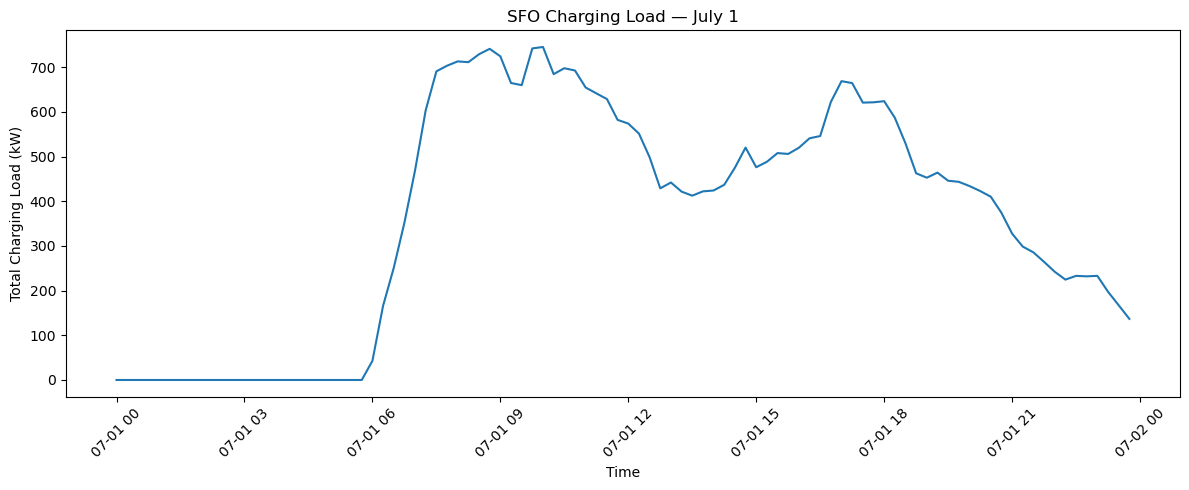

In [48]:
one_day = timeline[
    timeline["timestamp"].dt.date
    == pd.Timestamp("2026-07-01").date()
]

plt.figure(figsize=(12, 5))
plt.plot(one_day["timestamp"], one_day["load_kw"])

plt.xlabel("Time")
plt.ylabel("Total Charging Load (kW)")
plt.title("SFO Charging Load — July 1")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

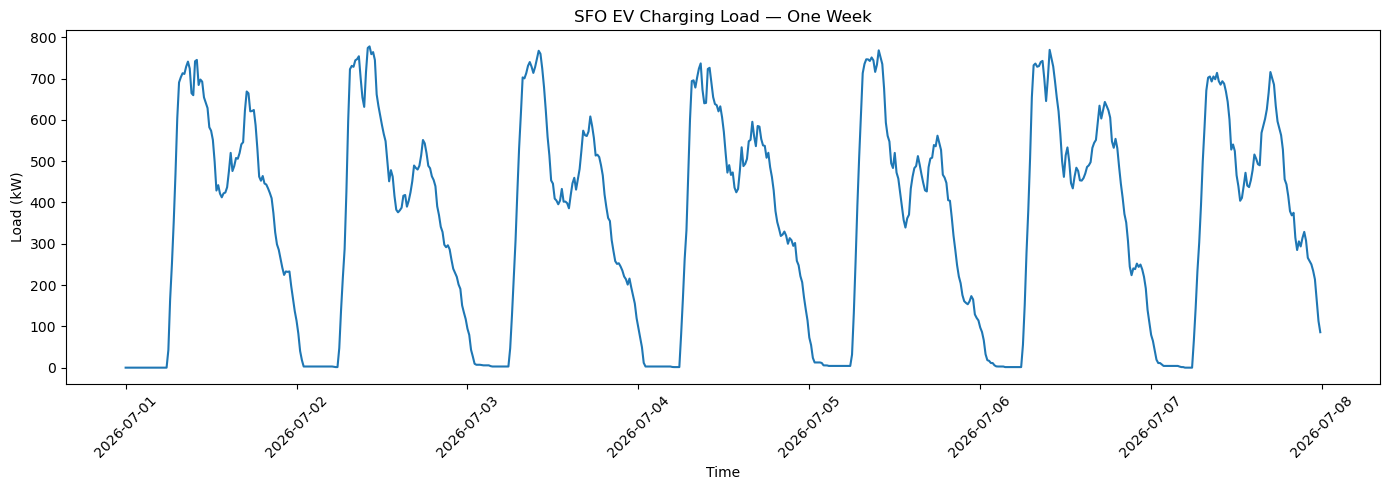

In [70]:
import matplotlib.pyplot as plt
import pandas as pd

week_start = pd.Timestamp("2026-07-01",  tz="America/Los_Angeles")
week_end = week_start + pd.Timedelta(days=7)

week = timeline[
    (timeline["timestamp"] >= week_start)
    & (timeline["timestamp"] < week_end)
]

plt.figure(figsize=(14, 5))

plt.plot(
    week["timestamp"],
    week["load_kw"]
)

plt.xlabel("Time")
plt.ylabel("Load (kW)")
plt.title("SFO EV Charging Load — One Week")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Sanity checks

In [ ]:
max_possible_kw = sum(
    port["power_kw"]
    for lot_ports in ports.values()
    for port in lot_ports
)

print("Maximum possible load:", max_possible_kw, "kW")
print("Observed peak:", timeline["load_kw"].max(), "kW")

assert timeline["load_kw"].max() <= max_possible_kw + 1e-9

In [ ]:
total_kwh = timeline["load_kw"].sum() * 0.25

print(f'total simulated energy: {total_kwh} kWh')


served = cars[cars["accepted"]].copy()

served["energy_delivered_kwh"] = (
    served["port_power_kw"] * served["charging_hours"]
)

car_energy_kwh = served["energy_delivered_kwh"].sum()


print(f'car energy delivered: {car_energy_kwh}')

In [ ]:
served = cars[cars["accepted"]].copy()

served["energy_delivered_kwh"] = (
    served["port_power_kw"] * served["charging_hours"]
)

expected_kwh = served["energy_delivered_kwh"].sum()

print("Timeline energy:", total_kwh)
print("Expected from cars:", expected_kwh)
print("Difference:", total_kwh - expected_kwh)

In [ ]:
print("Rows:", len(timeline))
print("Missing timestamps:", timeline["timestamp"].isna().sum())
print("Missing loads:", timeline["load_kw"].isna().sum())
print("Negative loads:", (timeline["load_kw"] < 0).sum())

assert len(timeline) == 2976
assert timeline["timestamp"].isna().sum() == 0
assert timeline["load_kw"].isna().sum() == 0
assert (timeline["load_kw"] < 0).sum() == 0

# Building the bill calculator

In [ ]:
tariff = {"SFO":{
    "fixed_charge": 2300,
    "on_peak_rate_summer": 0.11313,
    "off_peak_rate_summer": 0.09406,
    "off_peak_rate_winter": 0.0406,
    "demand_charge": 20,
    "on_peak_start": 16,
    "on_peak_end": 21}
}

bill = {"SFO"}


In [ ]:
bill["SFO"]["demand_